In [175]:
## Model Comparison

# Seven regression models were evaluated using the same train-test split.

# The comparison was based on:

# - Mean Absolute Error (MAE)
# - Mean Squared Error (MSE)
# - Root Mean Squared Error (RMSE)
# - Coefficient of Determination (R²)
# - Adjusted R² 
# The model with the highest R² score and lowest prediction errors was selected as the best-performing model.

In [176]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [10, 20, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [177]:
print("Best Parameters:")
print(grid_rf.best_params_)

print("\nBest Cross Validation Score:")
print(grid_rf.best_score_)

Best Parameters:
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross Validation Score:
0.8050524232098117


In [178]:
best_rf = grid_rf.best_estimator_

y_pred_best = best_rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_best)
mse = mean_squared_error(y_test, y_pred_best)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_best)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² :", r2)

MAE : 0.3271140672274751
RMSE: 0.5045713885354675
R² : 0.8057153985083529


In [51]:
cv_scores = cross_val_score(
    best_rf,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage R²:")
print(cv_scores.mean())

Cross Validation Scores:
[0.51768155 0.70463399 0.74213274 0.62696194 0.6822651 ]

Average R²:
0.6547350641391212


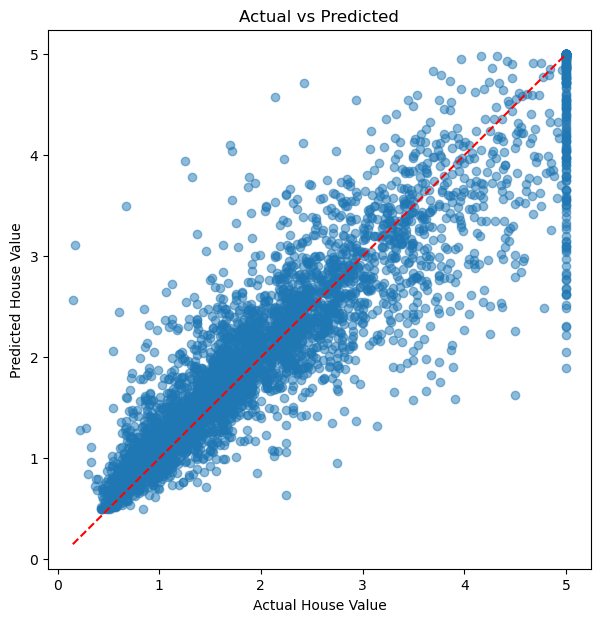

In [52]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_pred_best,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted")

plt.show()

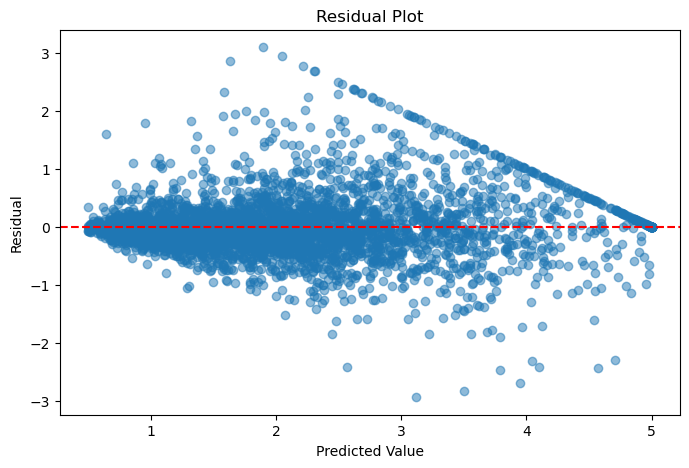

In [53]:
residuals = y_test - y_pred_best

plt.figure(figsize=(8,5))

plt.scatter(
    y_pred_best,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Value")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

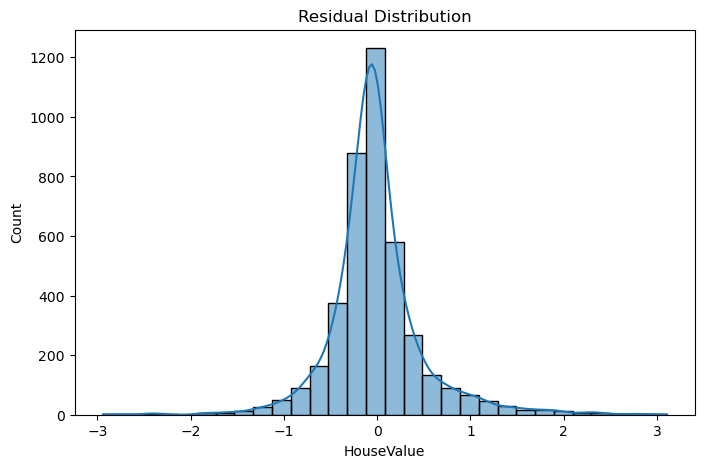

In [54]:
plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

In [55]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,MedInc,0.526842
5,AveOccup,0.138143
6,Latitude,0.088633
7,Longitude,0.088177
1,HouseAge,0.054128
2,AveRooms,0.044249
4,Population,0.030494
3,AveBedrms,0.029334


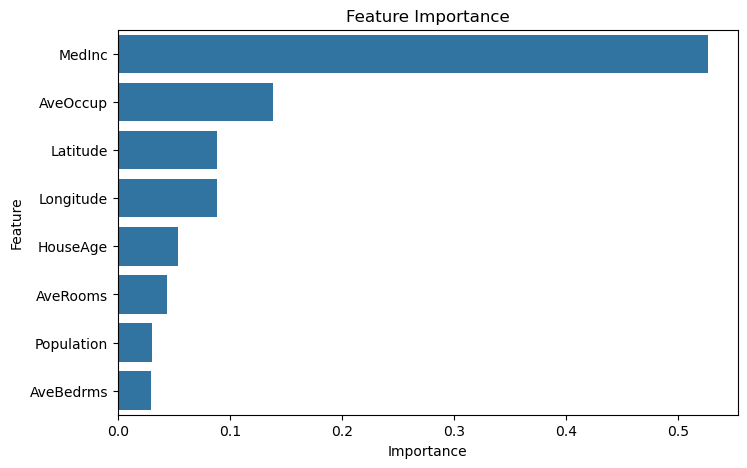

In [56]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [57]:
results.to_csv(
    "model_comparison_results.csv",
    index=False
)

importance.to_csv(
    "feature_importance.csv",
    index=False
)